# Customer Segmentation & Value Analysis
This notebook analyzes passenger booking behaviors, customer lifetime value, and demographic segments.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
base_dir = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
processed_dir = os.path.join(base_dir, 'data', 'processed')
figures_dir = os.path.join(base_dir, 'reports', 'figures')

df_bookings = pd.read_pickle(os.path.join(processed_dir, 'bookings_clean.pkl'))

### Customer Value Calculation

In [3]:
df_bookings['TotalSpend'] = df_bookings['TicketPrice'] + df_bookings['AncillaryRevenue']

customer_ltv = df_bookings.groupby('CustomerID').agg(
    TotalBookings=('BookingID', 'count'),
    TotalSpend=('TotalSpend', 'sum'),
    AvgAncillary=('AncillaryRevenue', 'mean'),
    PassengerType=('PassengerType', 'first'),
    LoyaltyTier=('LoyaltyTier', 'first')
).reset_index()

# Group by Passenger Type and Loyalty
segment_summary = customer_ltv.groupby(['PassengerType', 'LoyaltyTier'], dropna=False).agg(
    CustomerCount=('CustomerID', 'count'),
    AvgBookings=('TotalBookings', 'mean'),
    AvgSpend=('TotalSpend', 'mean')
).reset_index().fillna({'LoyaltyTier': 'None'})

segment_summary = segment_summary.sort_values('AvgSpend', ascending=False)
segment_summary

,PassengerType,LoyaltyTier,CustomerCount,AvgBookings,AvgSpend
0,Business,Gold,2674,15.004114,9125.796653
2,Business,Silver,3448,14.955626,8941.591555
3,Business,None,10499,14.911801,8923.615250
1,Business,Platinum,899,14.894327,8876.070133
4,Leisure,Gold,4899,15.216983,3969.536897
7,Leisure,None,19463,15.163952,3955.798416
6,Leisure,Silver,6469,15.176534,3953.742180
5,Leisure,Platinum,1649,15.065494,3952.769163


### Visualizations

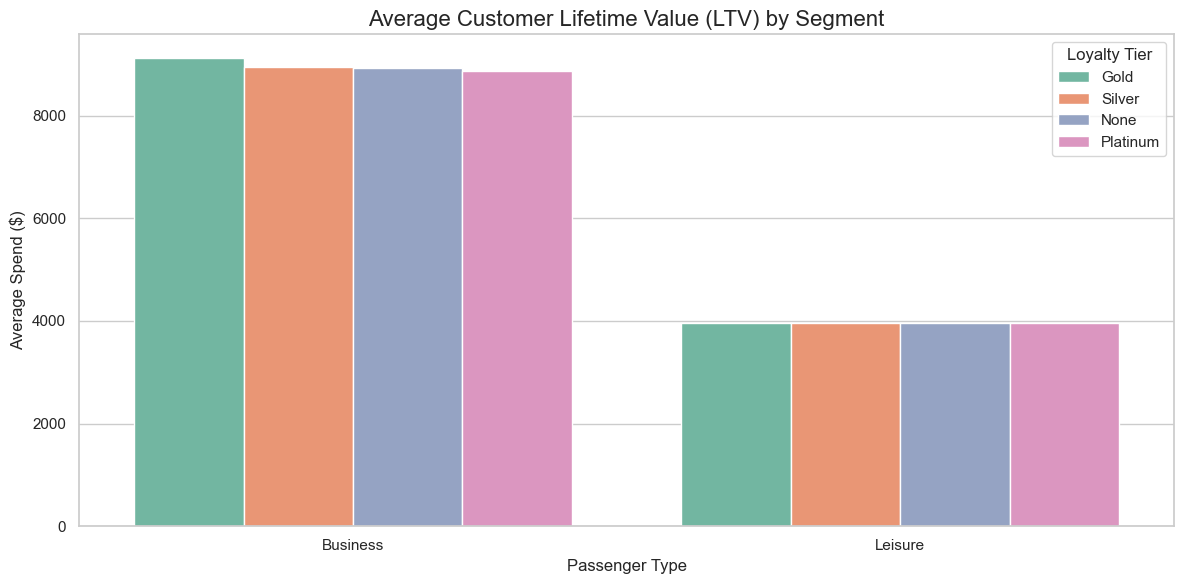

In [4]:
# Plot 1: Revenue by Passenger Type and Loyalty Tier
plt.figure(figsize=(12, 6))
sns.barplot(data=segment_summary, x='PassengerType', y='AvgSpend', hue='LoyaltyTier', palette='Set2')
plt.title('Average Customer Lifetime Value (LTV) by Segment', fontsize=16)
plt.ylabel('Average Spend ($)', fontsize=12)
plt.xlabel('Passenger Type', fontsize=12)
plt.legend(title='Loyalty Tier')
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'ltv_by_segment.png'))
plt.show()

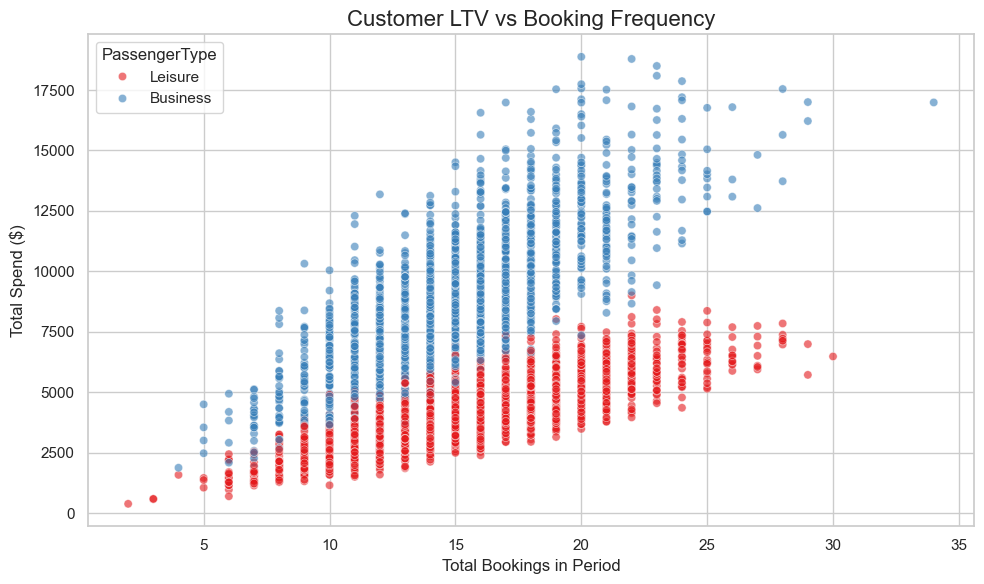

Customer segmentation analysis complete and figures saved.


In [5]:
# Plot 2: Scatter of Bookings vs Spend
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=customer_ltv.sample(n=min(5000, len(customer_ltv)), random_state=42), 
    x='TotalBookings', 
    y='TotalSpend', 
    hue='PassengerType',
    alpha=0.6,
    palette='Set1'
)
plt.title('Customer LTV vs Booking Frequency', fontsize=16)
plt.ylabel('Total Spend ($)', fontsize=12)
plt.xlabel('Total Bookings in Period', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'ltv_vs_frequency.png'))
plt.show()

print("Customer segmentation analysis complete and figures saved.")